In [ ]:
import sys
sys.path.insert(0, '../lib')

import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import warnings

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%config InlineBackend.figure_format = "retina"

In [ ]:
ds = sc.read_h5ad(common_data._sc_root / '01a_raw.h5ad')

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


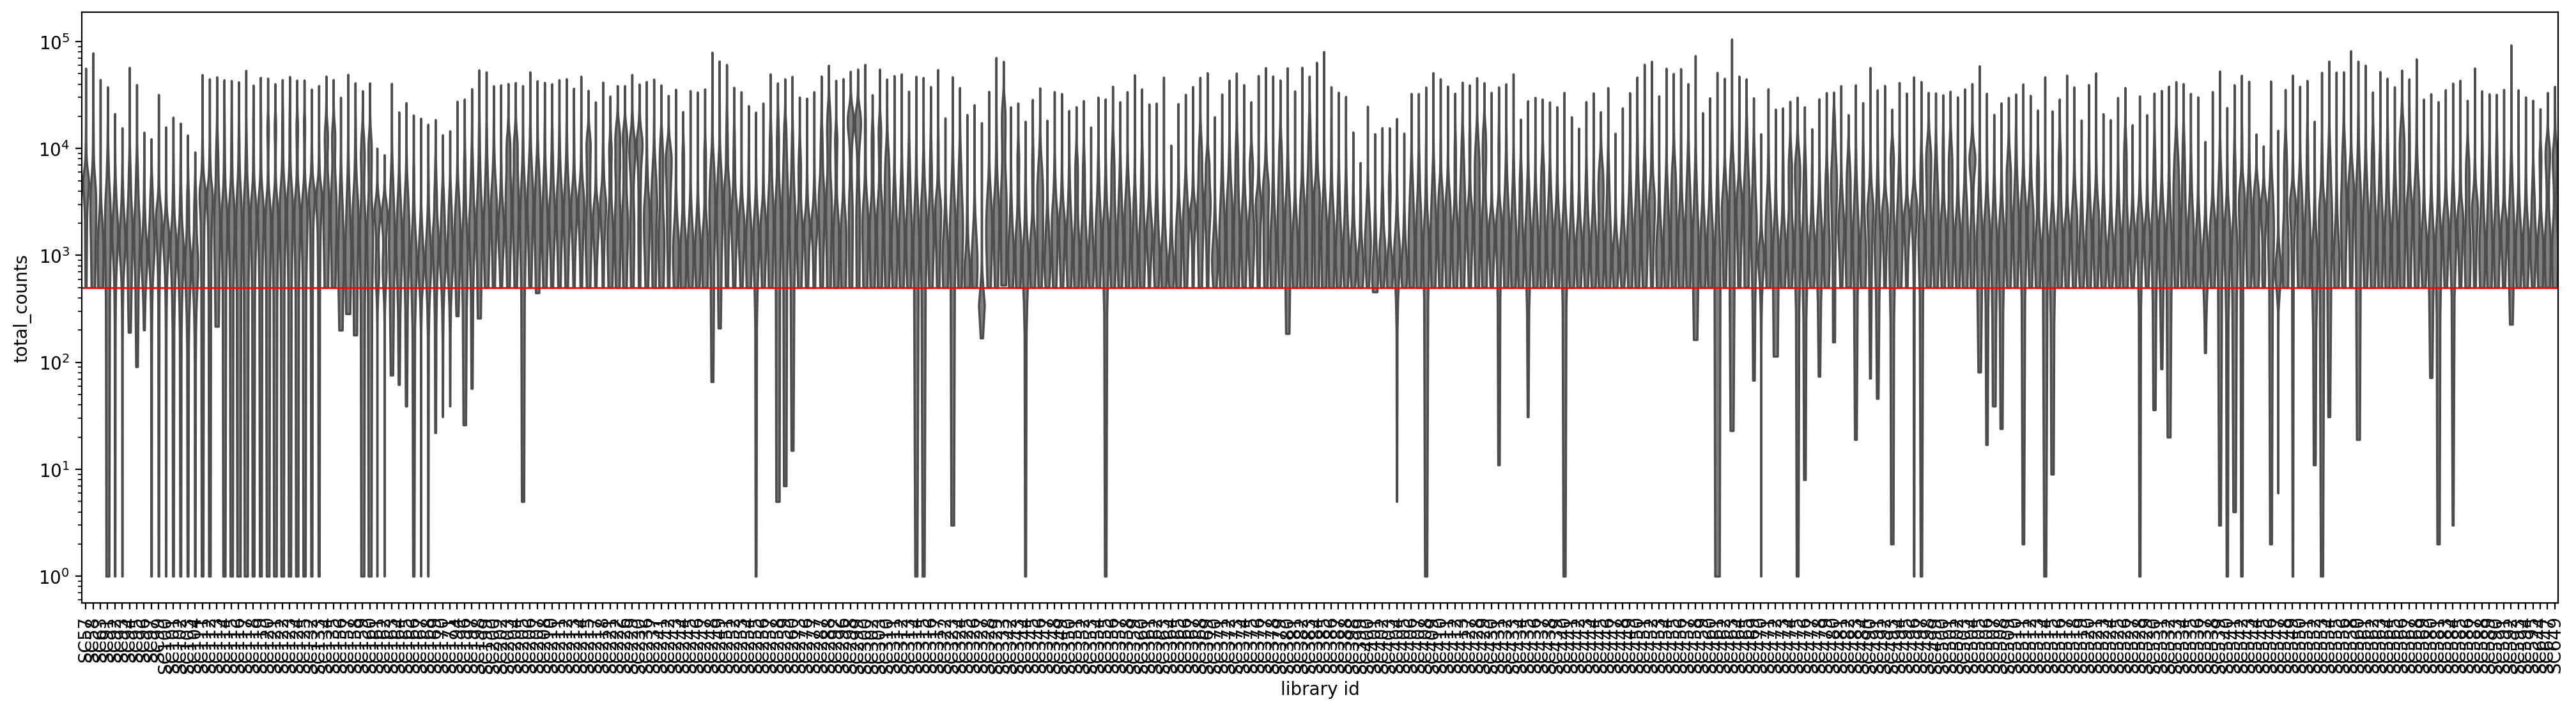

In [5]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(ds, "total_counts", groupby="library_id", size=0, log=True, ax=ax, show=False)
ax.axhline(500, c="red", lw=1)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)

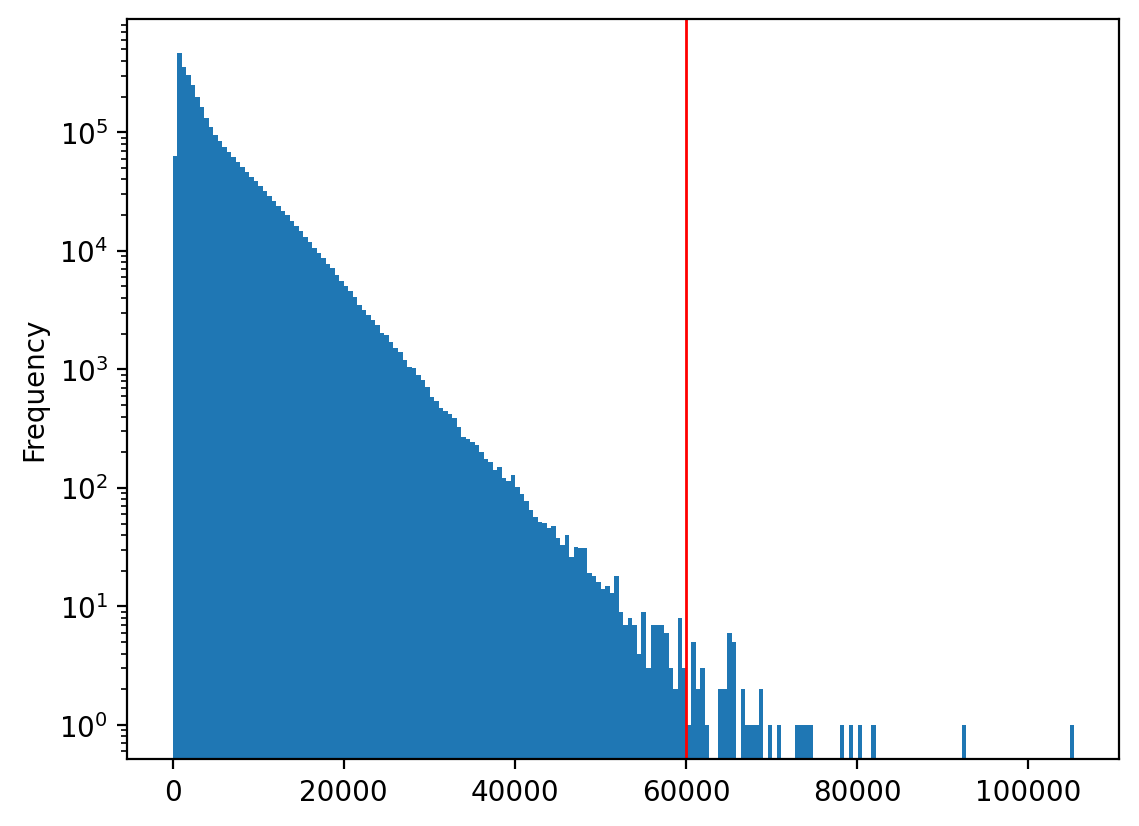

In [6]:
ax = ds.obs.total_counts.plot.hist(bins=200, log=True)
ax.axvline(60000, c="red", lw=1);

In [7]:
ds.shape

(3022609, 33550)

In [8]:
sc.pp.filter_genes(ds, min_cells=50)
sc.pp.filter_cells(ds, min_counts=200)
sc.pp.filter_cells(ds, max_counts=60000)

In [9]:
ds.shape

(3017191, 25141)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


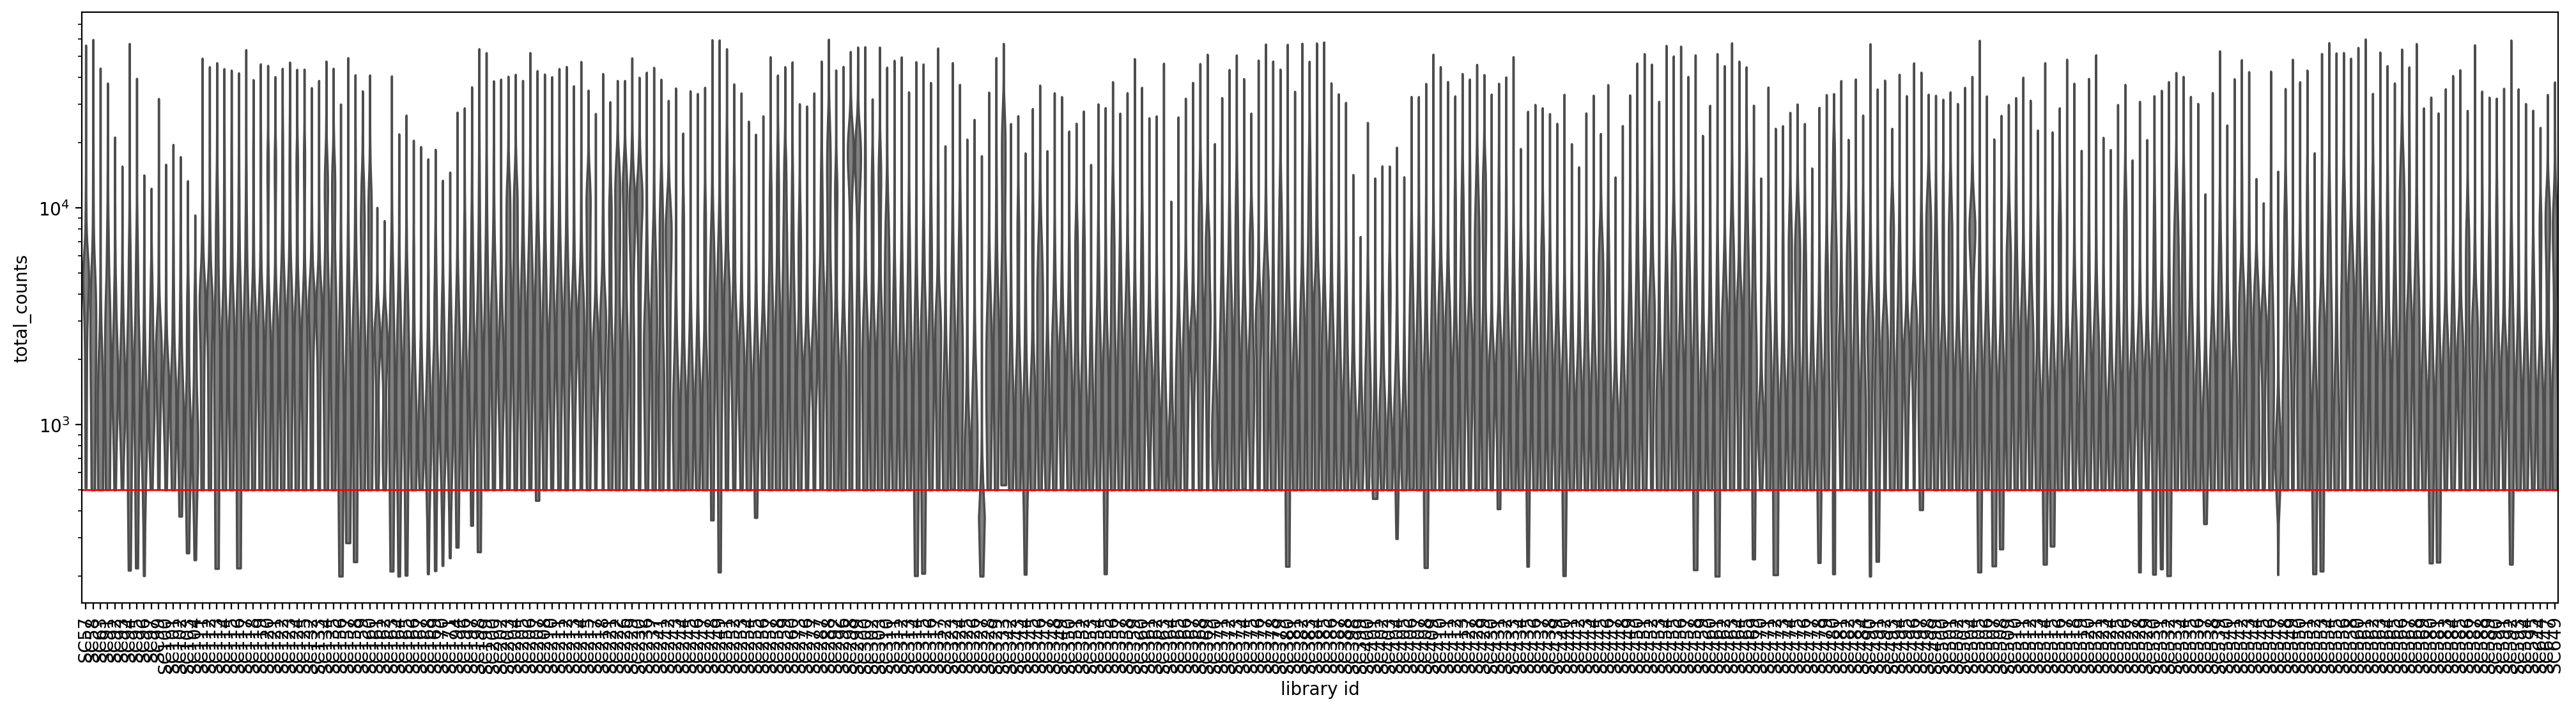

In [10]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(ds, "total_counts", groupby="library_id", size=0, log=True, ax=ax, show=False)
ax.axhline(500, c="red", lw=1)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)

In [11]:
counts_by_lib = ds.obs.groupby('library_id').total_counts.mean()

In [12]:
counts_by_lib[counts_by_lib.lt(500)]

library_id
SC327    437.024017
Name: total_counts, dtype: float32

In [13]:
ds.obs.groupby('individual').head(1).groupby('name').size()

name
AUXORA205       4
Duke_ozone      7
PASC           25
SCRIPT        266
SSc-ILD         2
dtype: int64

In [ ]:
ds.write_h5ad(common_data._sc_root / '01b_trimmed.h5ad')